# Single-Kernel Radial `f(r)` Optimization

This notebook takes the rotation-invariant kernel profile from `composite_rotation_invariance.ipynb`,
defines a **single radial kernel** by discrete values `f0 = f(r=0), f1 = f(r=1), ..., f10 = f(r=10)`,
and then optimizes those `f_i` values directly instead of searching over predefined kernel families.

Workflow:
1. Build the 10-degree rotation-invariant seed kernel from the saved composite kernel.
2. Extract its radial profile and reconstruct the shell-constant radial seed kernel.
3. Fit a baseline classifier using that radial seed kernel.
4. Learn improved `f_i` values on `train`, select the checkpoint on `val`, and report `test` accuracy/AUC.
5. Run dense full-image inference with the learned kernel and overlay the heatmap on one TIFF image.


In [10]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from scipy.ndimage import gaussian_filter, rotate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

from kernel_model.data import load_patches_from_folders, to_tensor_batch

EXP_DIR = Path("results/exp_022_mmr_nperFamily500_nComposition1250")
KERNEL_FILENAME = "composite_kernel.npy"
DATA_ROOT = None

TRAIN_SPLIT = "train"
VAL_SPLIT = "val"
TEST_SPLIT = "test"
RESIZE_PATCH = 128
MAX_PER_CLASS = None

SEED_ROTATION_STEP_DEG = 10
LEARNED_RADIUS_MAX = 20
FREEZE_OUTER_RADII = True

RESPONSE_MODE = "abs_max"  # "abs_max" or "mean_abs"
STANDARDIZE_PATCHES = False

EPOCHS = 15
BATCH_SIZE = 128
LR_F = 3e-2
LR_HEAD = 1e-2
LAMBDA_SMOOTH = 1e-3
LAMBDA_ANCHOR = 1e-1
LAMBDA_SCALE = 5e-2
THRESHOLD_GRID_SIZE = 181

EXAMPLE_IMAGE_PATH = Path("data/TIFF Images/malignantAnnotation/IMG015.tif")
DENSE_OVERLAY_ALPHA = 0.40
HEATMAP_SMOOTH_SIGMA = 1.2
SAVE_ARTIFACTS = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(min(8, max(1, os.cpu_count() or 1)))

OUT_DIR = EXP_DIR / f"radial_single_kernel_r{LEARNED_RADIUS_MAX}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using device: {DEVICE}")
print(f"Output dir: {OUT_DIR}")


Using device: cuda
Output dir: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20


In [2]:
def resolve_data_root(exp_dir: Path, data_root_override):
    if data_root_override is not None:
        return Path(data_root_override)
    cfg_path = exp_dir / "config.json"
    if cfg_path.exists():
        cfg = json.loads(cfg_path.read_text())
        return Path(cfg.get("data_root", "data/patches"))
    return Path("data/patches")


def load_split(root_dir: Path, split_name: str, resize_patch: int, max_per_class=None):
    Xin, Xout = load_patches_from_folders(
        root_dir,
        max_per_class=max_per_class,
        resize=(resize_patch, resize_patch),
        splits=(split_name,),
    )
    return Xin.astype(np.float32), Xout.astype(np.float32)


def integer_radius_bins(kernel_shape):
    h, w = kernel_shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    yy, xx = np.indices((h, w))
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    return np.floor(r).astype(np.int64)


def radial_profile_from_kernel(kernel2d: np.ndarray):
    radius_bins = integer_radius_bins(kernel2d.shape)
    max_r = int(radius_bins.max())
    radial_sum = np.bincount(radius_bins.ravel(), weights=kernel2d.ravel(), minlength=max_r + 1)
    radial_count = np.bincount(radius_bins.ravel(), minlength=max_r + 1)
    profile = radial_sum / np.maximum(radial_count, 1)
    return profile.astype(np.float32), radius_bins


def build_radial_basis(radius_bins: np.ndarray):
    max_r = int(radius_bins.max())
    basis = np.stack([(radius_bins == i).astype(np.float32) for i in range(max_r + 1)], axis=0)
    return basis.astype(np.float32)


def patch_standardize(x_t: torch.Tensor):
    mean = x_t.mean(dim=(2, 3), keepdim=True)
    std = x_t.std(dim=(2, 3), keepdim=True)
    std = torch.where(std < 1e-6, torch.ones_like(std), std)
    return (x_t - mean) / std


def make_xy_tensors(Xin_np: np.ndarray, Xout_np: np.ndarray, standardize: bool):
    X = np.concatenate([Xin_np, Xout_np], axis=0).astype(np.float32)
    y = np.concatenate([
        np.ones(len(Xin_np), dtype=np.float32),
        np.zeros(len(Xout_np), dtype=np.float32),
    ])
    X_t = to_tensor_batch(X, torch.device("cpu"))
    if standardize:
        X_t = patch_standardize(X_t)
    y_t = torch.from_numpy(y)
    return X_t.contiguous(), y_t.contiguous(), y.astype(np.int64)


def response_from_kernel(x_t: torch.Tensor, kernel2d_t: torch.Tensor, mode: str):
    out = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    if mode == "abs_max":
        return out.abs().amax(dim=(2, 3))[:, 0]
    if mode == "mean_abs":
        return out.abs().mean(dim=(2, 3))[:, 0]
    raise ValueError(f"Unknown response mode '{mode}'")


@torch.no_grad()
def extract_responses(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = response_from_kernel(xb, kernel2d_t, RESPONSE_MODE)
        feats.append(feat.detach().cpu().numpy())
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,), dtype=np.float32)


def metrics_from_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5):
    y_hat = (probs > float(threshold)).astype(np.int64)
    acc = accuracy_score(y_true, y_hat)
    auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else float("nan")
    return {"acc": float(acc), "auc": float(auc)}


def best_threshold_by_accuracy(y_true: np.ndarray, probs: np.ndarray, grid_size: int = 181):
    grid = np.linspace(0.05, 0.95, int(grid_size), dtype=np.float32)
    preds = probs[None, :] > grid[:, None]
    accs = (preds == y_true[None, :]).mean(axis=1)
    best_idx = int(np.argmax(accs))
    return float(grid[best_idx]), float(accs[best_idx])


def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def ensure_example_image(path: Path):
    if path.exists():
        return path
    candidates = sorted(Path("data/TIFF Images/malignantAnnotation").glob("*.tif"))
    if not candidates:
        raise FileNotFoundError(f"Could not find example image and no fallback TIFFs under malignantAnnotation.")
    return candidates[0]


Original composite kernel shape: (31, 31)
Rotation-invariant seed uses 36 angles: 0..350 step 10
Total radial shells in kernel: 22
Learnable shells: 0..5
Frozen outer shells: 6..21

Seed radial coefficients used as the initial f(r):
  f00 = -2.3293695e-03
  f01 = +8.7633816e-04
  f02 = -8.9594861e-05
  f03 = +1.7263779e-05
  f04 = +1.0518136e-04
  f05 = +2.8132265e-05


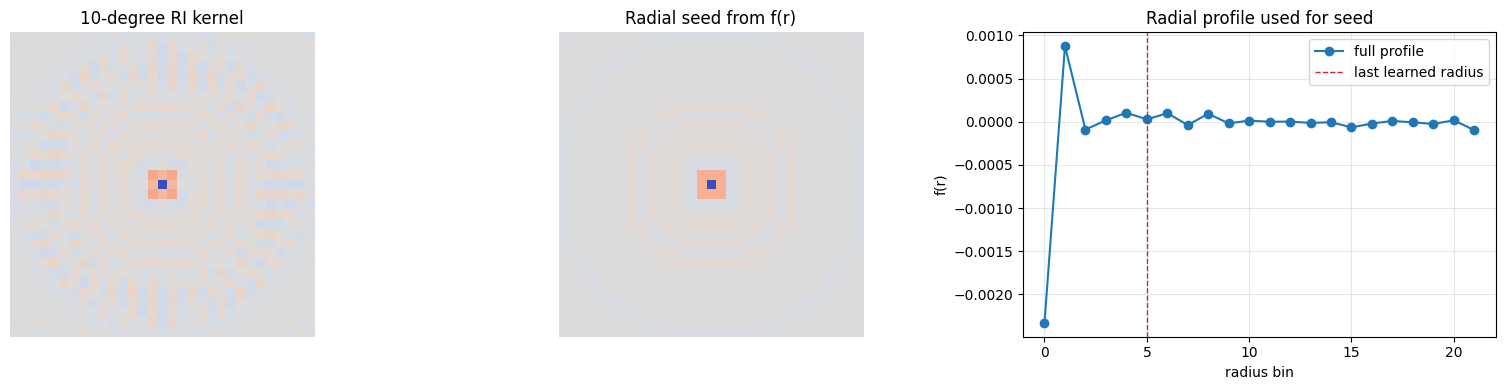

In [3]:
kernel_path = EXP_DIR / KERNEL_FILENAME
if not kernel_path.exists():
    raise FileNotFoundError(f"Missing kernel file: {kernel_path}")

base_kernel = np.load(kernel_path).astype(np.float32)
if base_kernel.ndim != 2:
    raise ValueError(f"Expected a 2D kernel, got shape={base_kernel.shape}")

rotated_kernels = [
    rotate(base_kernel, angle=angle, reshape=False, order=1, mode="nearest", prefilter=False)
    for angle in range(0, 360, SEED_ROTATION_STEP_DEG)
]
rotation_invariant_kernel = np.mean(np.stack(rotated_kernels, axis=0), axis=0).astype(np.float32)

f_seed_full, radius_bins = radial_profile_from_kernel(rotation_invariant_kernel)
basis_np = build_radial_basis(radius_bins)
seed_radial_kernel = np.einsum("r,rhw->hw", f_seed_full, basis_np).astype(np.float32)

full_radius_count = len(f_seed_full)
if FREEZE_OUTER_RADII:
    learnable_len = min(int(LEARNED_RADIUS_MAX), full_radius_count - 1) + 1
    f_tail_fixed = f_seed_full[learnable_len:].copy()
else:
    learnable_len = full_radius_count
    f_tail_fixed = np.zeros((0,), dtype=np.float32)

f_seed_learn = f_seed_full[:learnable_len].copy()

print(f"Original composite kernel shape: {base_kernel.shape}")
print(f"Rotation-invariant seed uses {len(rotated_kernels)} angles: 0..350 step {SEED_ROTATION_STEP_DEG}")
print(f"Total radial shells in kernel: {full_radius_count}")
print(f"Learnable shells: 0..{learnable_len - 1}")
if FREEZE_OUTER_RADII:
    print(f"Frozen outer shells: {learnable_len}..{full_radius_count - 1}")

print("\nSeed radial coefficients used as the initial f(r):")
for idx, value in enumerate(f_seed_learn):
    print(f"  f{idx:02d} = {value:+.7e}")

diff = rotation_invariant_kernel - seed_radial_kernel
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

vmax = max(
    float(np.max(np.abs(rotation_invariant_kernel))),
    float(np.max(np.abs(seed_radial_kernel))),
) + 1e-12

axes[0].imshow(rotation_invariant_kernel, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[0].set_title("10-degree RI kernel")
axes[0].axis("off")

axes[1].imshow(seed_radial_kernel, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[1].set_title("Radial seed from f(r)")
axes[1].axis("off")

# axes[2].imshow(diff, cmap="coolwarm")
# axes[2].set_title("RI kernel - radial seed")
# axes[2].axis("off")

radius_axis = np.arange(len(f_seed_full))
axes[2].plot(radius_axis, f_seed_full, marker="o", linewidth=1.5, label="full profile")
axes[2].axvline(learnable_len - 1, color="tab:red", linestyle="--", linewidth=1, label="last learned radius")
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Radial profile used for seed")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


In [4]:
data_root = resolve_data_root(EXP_DIR, DATA_ROOT)
print(f"Data root: {data_root}")

Xin_train, Xout_train = load_split(data_root, TRAIN_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)
Xin_val, Xout_val = load_split(data_root, VAL_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)
Xin_test, Xout_test = load_split(data_root, TEST_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)

print(f"Train split: Xin={Xin_train.shape}, Xout={Xout_train.shape}")
print(f"Val split  : Xin={Xin_val.shape}, Xout={Xout_val.shape}")
print(f"Test split : Xin={Xin_test.shape}, Xout={Xout_test.shape}")

X_train_t, y_train_t, y_train = make_xy_tensors(Xin_train, Xout_train, STANDARDIZE_PATCHES)
X_val_t, y_val_t, y_val = make_xy_tensors(Xin_val, Xout_val, STANDARDIZE_PATCHES)
X_test_t, y_test_t, y_test = make_xy_tensors(Xin_test, Xout_test, STANDARDIZE_PATCHES)

seed_kernel_t = torch.from_numpy(seed_radial_kernel).to(DEVICE)
seed_train_resp = extract_responses(X_train_t, seed_kernel_t, BATCH_SIZE)
seed_val_resp = extract_responses(X_val_t, seed_kernel_t, BATCH_SIZE)
seed_test_resp = extract_responses(X_test_t, seed_kernel_t, BATCH_SIZE)

seed_mu = float(seed_train_resp.mean())
seed_std = float(seed_train_resp.std())
seed_std = seed_std if seed_std > 1e-8 else 1.0

seed_clf = LogisticRegression(max_iter=1000)
seed_clf.fit(((seed_train_resp - seed_mu) / seed_std).reshape(-1, 1), y_train)

seed_probs_train = seed_clf.predict_proba(((seed_train_resp - seed_mu) / seed_std).reshape(-1, 1))[:, 1]
seed_probs_val = seed_clf.predict_proba(((seed_val_resp - seed_mu) / seed_std).reshape(-1, 1))[:, 1]
seed_probs_test = seed_clf.predict_proba(((seed_test_resp - seed_mu) / seed_std).reshape(-1, 1))[:, 1]

seed_threshold_val, seed_val_acc_tuned = best_threshold_by_accuracy(y_val, seed_probs_val, THRESHOLD_GRID_SIZE)

seed_results = {
    "val_05": metrics_from_probs(y_val, seed_probs_val, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, seed_probs_val, threshold=seed_threshold_val),
    "test_05": metrics_from_probs(y_test, seed_probs_test, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, seed_probs_test, threshold=seed_threshold_val),
    "threshold_val": float(seed_threshold_val),
    "mu": seed_mu,
    "std": seed_std,
    "w": float(seed_clf.coef_[0, 0]),
    "b": float(seed_clf.intercept_[0]),
}

print("Seed radial-kernel baseline metrics:")
print(
    f"  Val  | AUC={seed_results['val_05']['auc']:.6f} ACC@0.5={seed_results['val_05']['acc']:.6f} "
    f"ACC@thr_val={seed_results['val_tuned']['acc']:.6f} (thr_val={seed_results['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={seed_results['test_05']['auc']:.6f} ACC@0.5={seed_results['test_05']['acc']:.6f} "
    f"ACC@thr_val={seed_results['test_tuned']['acc']:.6f}"
)


Data root: data/patches


Train split: Xin=(2900, 128, 128), Xout=(3430, 128, 128)
Val split  : Xin=(1080, 128, 128), Xout=(790, 128, 128)
Test split : Xin=(1040, 128, 128), Xout=(830, 128, 128)
Seed radial-kernel baseline metrics:
  Val  | AUC=0.889848 ACC@0.5=0.818182 ACC@thr_val=0.838503 (thr_val=0.420)
  Test | AUC=0.882471 ACC@0.5=0.800000 ACC@thr_val=0.802139


In [5]:
basis_t = torch.from_numpy(basis_np).to(DEVICE)
f_seed_learn_t = torch.from_numpy(f_seed_learn).to(DEVICE)
f_tail_fixed_t = torch.from_numpy(f_tail_fixed).to(DEVICE)
seed_norm = float(np.linalg.norm(f_seed_full))

def kernel_from_learnable(f_learn_t: torch.Tensor):
    if f_tail_fixed_t.numel() > 0:
        f_full_t = torch.cat([f_learn_t, f_tail_fixed_t], dim=0)
    else:
        f_full_t = f_learn_t
    kernel_t = torch.einsum("r,rhw->hw", f_full_t, basis_t)
    return kernel_t, f_full_t

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

f_learn = torch.nn.Parameter(f_seed_learn_t.clone())
head_w = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float32, device=DEVICE))
head_b = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=DEVICE))

optimizer = torch.optim.Adam(
    [
        {"params": [f_learn], "lr": LR_F},
        {"params": [head_w, head_b], "lr": LR_HEAD},
    ]
)
loss_fn = torch.nn.BCEWithLogitsLoss()

best_state = None
best_val_auc = -float("inf")
history = []

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    n_seen = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        kernel_t, f_full_t = kernel_from_learnable(f_learn)
        feat = response_from_kernel(xb, kernel_t, RESPONSE_MODE)
        logits = head_w * feat + head_b

        loss_cls = loss_fn(logits, yb)
        loss_smooth = torch.mean((f_learn[1:] - f_learn[:-1]) ** 2) if f_learn.numel() > 1 else torch.tensor(0.0, device=DEVICE)
        loss_anchor = torch.mean((f_learn - f_seed_learn_t) ** 2)
        loss_scale = (torch.norm(f_full_t) - seed_norm) ** 2
        loss = loss_cls + LAMBDA_SMOOTH * loss_smooth + LAMBDA_ANCHOR * loss_anchor + LAMBDA_SCALE * loss_scale

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(loss.item()) * batch_n
        n_seen += batch_n

    kernel_val_t, _ = kernel_from_learnable(f_learn)
    val_resp = extract_responses(X_val_t, kernel_val_t.detach(), BATCH_SIZE)
    val_probs = sigmoid_np(float(head_w.detach().cpu()) * val_resp + float(head_b.detach().cpu()))
    val_metrics = metrics_from_probs(y_val, val_probs, threshold=0.5)

    history.append(
        {
            "epoch": int(epoch),
            "loss": float(total_loss / max(n_seen, 1)),
            "val_auc": float(val_metrics["auc"]),
            "val_acc": float(val_metrics["acc"]),
            "optimizer_head_w": float(head_w.detach().cpu()),
            "optimizer_head_b": float(head_b.detach().cpu()),
        }
    )

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        best_state = {
            "epoch": int(epoch),
            "f_learn": f_learn.detach().cpu().clone(),
            "optimizer_head_w": float(head_w.detach().cpu()),
            "optimizer_head_b": float(head_b.detach().cpu()),
            "val_auc": float(val_metrics["auc"]),
            "val_acc": float(val_metrics["acc"]),
        }

    print(
        f"epoch={epoch:02d} "
        f"loss={history[-1]['loss']:.6f} "
        f"val_auc={val_metrics['auc']:.6f} "
        f"val_acc={val_metrics['acc']:.6f} "
        f"w={float(head_w.detach().cpu()):+.4f} "
        f"b={float(head_b.detach().cpu()):+.4f}"
    )

print("\nRestoring best checkpoint:")
print(best_state)

f_best = best_state["f_learn"].to(DEVICE)
optimizer_head_w_best = float(best_state["optimizer_head_w"])
optimizer_head_b_best = float(best_state["optimizer_head_b"])

kernel_best_t, f_best_full_t = kernel_from_learnable(f_best)
kernel_best = kernel_best_t.detach().cpu().numpy().astype(np.float32)
f_best_full = f_best_full_t.detach().cpu().numpy().astype(np.float32)

train_resp_best = extract_responses(X_train_t, kernel_best_t.detach(), BATCH_SIZE)
val_resp_best = extract_responses(X_val_t, kernel_best_t.detach(), BATCH_SIZE)
test_resp_best = extract_responses(X_test_t, kernel_best_t.detach(), BATCH_SIZE)

calib_mu_best = float(train_resp_best.mean())
calib_std_best = float(train_resp_best.std())
calib_std_best = calib_std_best if calib_std_best > 1e-8 else 1.0

calib_clf = LogisticRegression(max_iter=1000)
calib_clf.fit(((train_resp_best - calib_mu_best) / calib_std_best).reshape(-1, 1), y_train)

calib_w_best = float(calib_clf.coef_[0, 0])
calib_b_best = float(calib_clf.intercept_[0])

train_probs_best = calib_clf.predict_proba(((train_resp_best - calib_mu_best) / calib_std_best).reshape(-1, 1))[:, 1]
val_probs_best = calib_clf.predict_proba(((val_resp_best - calib_mu_best) / calib_std_best).reshape(-1, 1))[:, 1]
test_probs_best = calib_clf.predict_proba(((test_resp_best - calib_mu_best) / calib_std_best).reshape(-1, 1))[:, 1]

best_threshold_val, best_val_acc_tuned = best_threshold_by_accuracy(y_val, val_probs_best, THRESHOLD_GRID_SIZE)

learned_results = {
    "val_05": metrics_from_probs(y_val, val_probs_best, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs_best, threshold=best_threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs_best, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs_best, threshold=best_threshold_val),
    "threshold_val": float(best_threshold_val),
    "best_epoch": int(best_state["epoch"]),
    "optimizer_head_w": optimizer_head_w_best,
    "optimizer_head_b": optimizer_head_b_best,
    "calib_mu": calib_mu_best,
    "calib_std": calib_std_best,
    "calib_w": calib_w_best,
    "calib_b": calib_b_best,
}

print("\nCalibrated learned radial-kernel metrics:")
print(
    f"  Val  | AUC={learned_results['val_05']['auc']:.6f} ACC@0.5={learned_results['val_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results['val_tuned']['acc']:.6f} (thr_val={learned_results['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={learned_results['test_05']['auc']:.6f} ACC@0.5={learned_results['test_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results['test_tuned']['acc']:.6f}"
)

print("\nOptimized learnable coefficients:")
for idx, value in enumerate(f_best_full[:learnable_len]):
    print(f"  f{idx:02d} = {value:+.7e}")

results_summary = {
    "seed": seed_results,
    "learned": learned_results,
    "f_seed_full": [float(x) for x in f_seed_full],
    "f_learned_full": [float(x) for x in f_best_full],
    "history": history,
    "response_mode": RESPONSE_MODE,
    "standardize_patches": bool(STANDARDIZE_PATCHES),
    "freeze_outer_radii": bool(FREEZE_OUTER_RADII),
    "learned_radius_max": int(learnable_len - 1),
}

if SAVE_ARTIFACTS:
    np.save(OUT_DIR / "f_seed_full.npy", f_seed_full.astype(np.float32))
    np.save(OUT_DIR / "f_learned_full.npy", f_best_full.astype(np.float32))
    np.save(OUT_DIR / "kernel_seed_radial.npy", seed_radial_kernel.astype(np.float32))
    np.save(OUT_DIR / "kernel_learned_radial.npy", kernel_best.astype(np.float32))
    (OUT_DIR / "radial_single_kernel_summary.json").write_text(json.dumps(results_summary, indent=2))
    print(f"\nSaved kernel artifacts to {OUT_DIR}")


epoch=01 loss=0.740010 val_auc=0.893080 val_acc=0.650802 w=+0.7711 b=-0.3270
epoch=02 loss=0.669818 val_auc=0.895340 val_acc=0.669519 w=+0.7528 b=-0.5045
epoch=03 loss=0.661580 val_auc=0.897248 val_acc=0.769519 w=+0.7155 b=-0.7046
epoch=04 loss=0.658075 val_auc=0.895986 val_acc=0.694118 w=+0.6133 b=-0.9072
epoch=05 loss=0.638498 val_auc=0.895790 val_acc=0.703743 w=+0.5912 b=-1.1164
epoch=06 loss=0.632977 val_auc=0.895776 val_acc=0.831016 w=+0.5204 b=-1.3206
epoch=07 loss=0.621721 val_auc=0.895659 val_acc=0.834759 w=+0.4878 b=-1.5254

Restoring best checkpoint:
{'epoch': 3, 'f_learn': tensor([-0.0050, -0.0088, -0.0057,  0.0002,  0.0116,  0.0290]), 'optimizer_head_w': 0.7155181169509888, 'optimizer_head_b': -0.7045802474021912, 'val_auc': 0.897248007501172, 'val_acc': 0.7695187165775401}

Calibrated learned radial-kernel metrics:
  Val  | AUC=0.897248 ACC@0.5=0.832086 ACC@thr_val=0.847059 (thr_val=0.350)
  Test | AUC=0.909413 ACC@0.5=0.841711 ACC@thr_val=0.840642

Optimized learnable coe

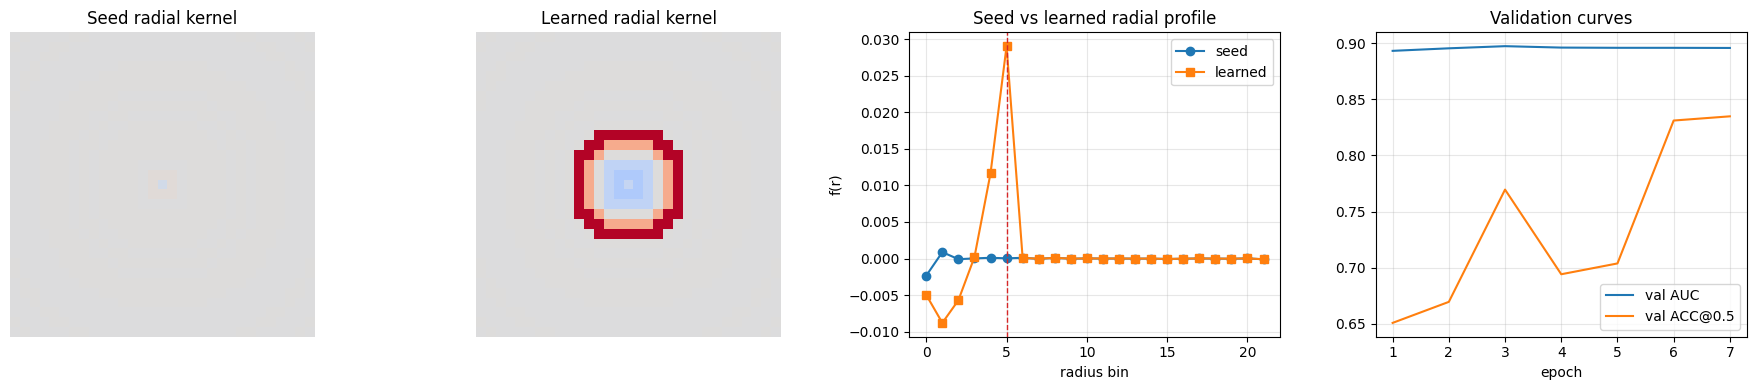

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

vmax = max(float(np.max(np.abs(seed_radial_kernel))), float(np.max(np.abs(kernel_best)))) + 1e-12

axes[0].imshow(seed_radial_kernel, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[0].set_title("Seed radial kernel")
axes[0].axis("off")

axes[1].imshow(kernel_best, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[1].set_title("Learned radial kernel")
axes[1].axis("off")

axes[2].plot(np.arange(len(f_seed_full)), f_seed_full, marker="o", linewidth=1.5, label="seed")
axes[2].plot(np.arange(len(f_best_full)), f_best_full, marker="s", linewidth=1.5, label="learned")
axes[2].axvline(learnable_len - 1, color="tab:red", linestyle="--", linewidth=1)
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Seed vs learned radial profile")
axes[2].grid(alpha=0.3)
axes[2].legend()

epochs = np.array([row["epoch"] for row in history], dtype=int)
val_auc = np.array([row["val_auc"] for row in history], dtype=np.float32)
val_acc = np.array([row["val_acc"] for row in history], dtype=np.float32)
axes[3].plot(epochs, val_auc, label="val AUC")
axes[3].plot(epochs, val_acc, label="val ACC@0.5")
axes[3].set_xlabel("epoch")
axes[3].set_title("Validation curves")
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()


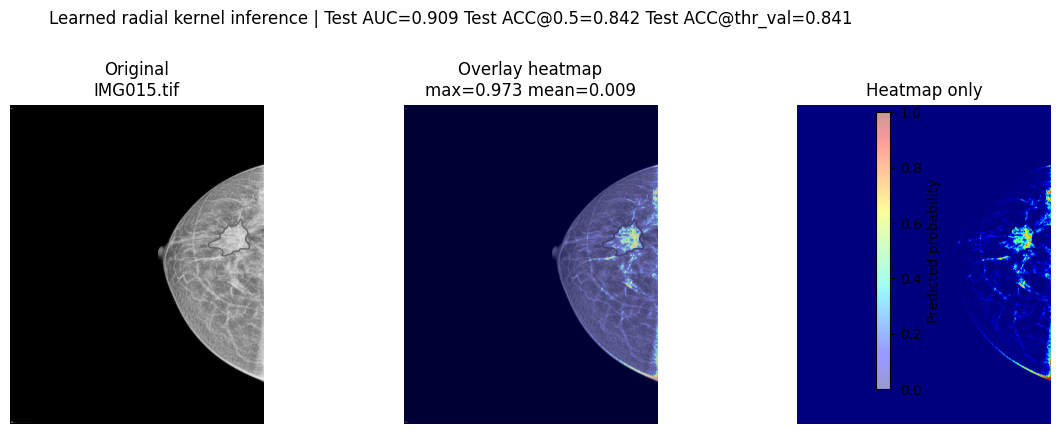

Saved heatmap figure: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r5/IMG015_learned_radial_heatmap.png
Saved probability map: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r5/IMG015_learned_radial_prob_map.npy


In [7]:
example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
img_arr = np.array(Image.open(example_path).convert("L"), dtype=np.float32) / 255.0

x_img_t = to_tensor_batch(img_arr[None, ...].astype(np.float32), torch.device("cpu"))
if STANDARDIZE_PATCHES:
    x_img_t = patch_standardize(x_img_t)

with torch.no_grad():
    xb = x_img_t.to(DEVICE, non_blocking=True)
    out = F.conv2d(xb, torch.from_numpy(kernel_best).to(DEVICE)[None, None], padding=kernel_best.shape[-1] // 2)[0, 0]
    feature_map = out.abs().detach().cpu().numpy().astype(np.float32)

prob_map = sigmoid_np(calib_w_best * ((feature_map - calib_mu_best) / calib_std_best) + calib_b_best).astype(np.float32)
prob_map_vis = gaussian_filter(prob_map, sigma=float(HEATMAP_SMOOTH_SIGMA)) if HEATMAP_SMOOTH_SIGMA > 0 else prob_map

image_score_max = float(prob_map.max())
image_score_mean = float(prob_map.mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(img_arr, cmap="gray")
axes[0].set_title(f"Original\n{example_path.name}")
axes[0].axis("off")

axes[1].imshow(img_arr, cmap="gray")
im = axes[1].imshow(prob_map_vis, cmap="jet", alpha=DENSE_OVERLAY_ALPHA, vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[1].set_title(
    "Overlay heatmap\n"
    f"max={image_score_max:.3f} mean={image_score_mean:.3f}"
)
axes[1].axis("off")

axes[2].imshow(prob_map_vis, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[2].set_title("Heatmap only")
axes[2].axis("off")

fig.suptitle(
    "Learned radial kernel inference | "
    f"Test AUC={learned_results['test_05']['auc']:.3f} "
    f"Test ACC@0.5={learned_results['test_05']['acc']:.3f} "
    f"Test ACC@thr_val={learned_results['test_tuned']['acc']:.3f}",
    y=1.03,
)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Predicted probability")
fig.subplots_adjust(top=0.82, wspace=0.05)
plt.show()

if SAVE_ARTIFACTS:
    heatmap_fig_path = OUT_DIR / f"{example_path.stem}_learned_radial_heatmap.png"
    prob_map_path = OUT_DIR / f"{example_path.stem}_learned_radial_prob_map.npy"
    fig.savefig(heatmap_fig_path, dpi=260, bbox_inches="tight")
    np.save(prob_map_path, prob_map)
    print(f"Saved heatmap figure: {heatmap_fig_path}")
    print(f"Saved probability map: {prob_map_path}")


mono epoch=01 loss=0.645048 val_auc=0.894762 val_acc=0.798396 w=+0.9143 b=-1.0458
mono epoch=02 loss=0.628864 val_auc=0.895207 val_acc=0.830481 w=+1.0263 b=-1.3373
mono epoch=03 loss=0.614520 val_auc=0.895928 val_acc=0.805348 w=+1.1340 b=-1.6273
mono epoch=04 loss=0.601963 val_auc=0.897336 val_acc=0.835294 w=+1.1907 b=-1.9344
mono epoch=05 loss=0.589328 val_auc=0.898923 val_acc=0.775936 w=+1.2030 b=-2.2579
mono epoch=06 loss=0.578105 val_auc=0.900970 val_acc=0.847594 w=+1.2840 b=-2.5184
mono epoch=07 loss=0.565547 val_auc=0.902467 val_acc=0.831551 w=+1.3261 b=-2.7916

Restoring best monotone checkpoint:
{'epoch': 7, 'raw_delta': tensor([-13.4917, -13.2889, -13.2301, -13.1871, -13.1348,  -3.8383,  -9.3082,
        -12.6280,  -8.6243, -12.1511, -11.9031, -11.7025, -11.4679, -11.2376,
        -11.0354, -10.8354, -10.7129, -10.5992, -10.5326, -10.4654, -10.4455,
         -7.3237]), 'optimizer_head_w': 1.3261041641235352, 'optimizer_head_b': -2.7916431427001953, 'val_auc': 0.902467182372245

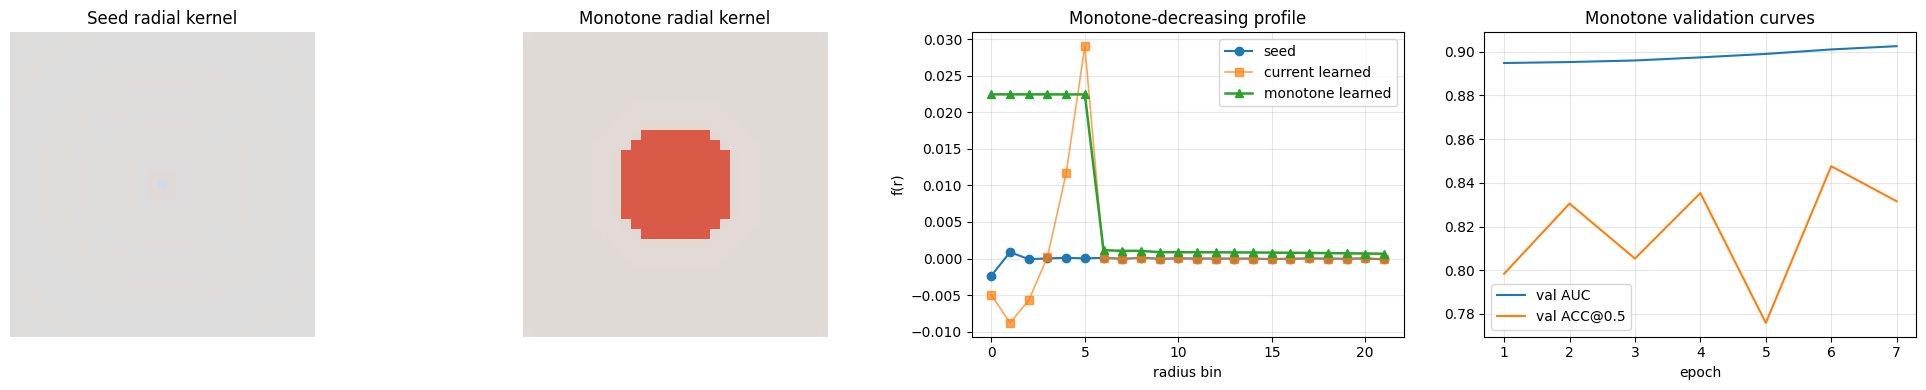

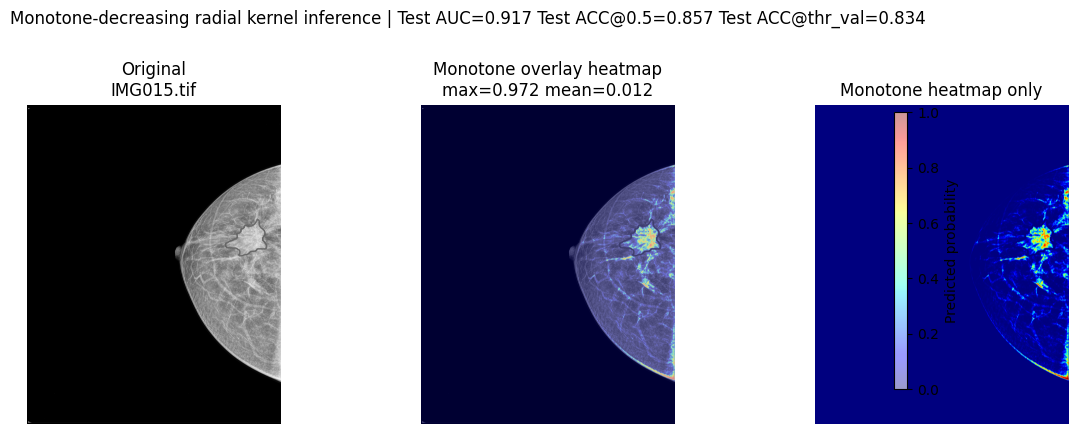


Saved monotone artifacts to results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r5/monotone_decreasing


In [8]:

# Optional: monotone-decreasing radial fit.
# This version is most natural with absolute response modes such as `abs_max` or `mean_abs`,
# because the patch feature already discards the kernel sign.
from sklearn.isotonic import IsotonicRegression

MONO_EPOCHS = EPOCHS
MONO_LR_PROFILE = LR_F * 0.5
MONO_LR_HEAD = LR_HEAD
MONO_LAMBDA_ANCHOR = 5e-2
MONO_LAMBDA_SCALE = LAMBDA_SCALE
MONO_LAMBDA_EDGE = 5e-2
MONO_OUT_DIR = OUT_DIR / "monotone_decreasing"
MONO_OUT_DIR.mkdir(parents=True, exist_ok=True)

if RESPONSE_MODE not in {"abs_max", "mean_abs"}:
    raise ValueError("This monotone cell expects an absolute response mode such as 'abs_max' or 'mean_abs'.")

mono_basis_t = basis_t if "basis_t" in globals() else torch.from_numpy(basis_np).to(DEVICE)
mono_train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

mono_len = full_radius_count
mono_radius = np.arange(mono_len, dtype=np.float32)
mono_reference = np.abs(f_best_full[:mono_len] if "f_best_full" in globals() else f_seed_full[:mono_len]).astype(np.float32)
mono_iso = IsotonicRegression(increasing=False, out_of_bounds="clip")
mono_init = mono_iso.fit_transform(mono_radius, mono_reference).astype(np.float32)
mono_init = np.maximum(mono_init, 0.0)


def inverse_softplus_np(x):
    x = np.asarray(x, dtype=np.float32)
    x = np.maximum(x, 1e-6)
    return np.where(x > 20.0, x, np.log(np.expm1(x)))


def monotone_profile_from_raw(raw_delta_t: torch.Tensor):
    delta_t = F.softplus(raw_delta_t)
    return torch.flip(torch.cumsum(torch.flip(delta_t, dims=[0]), dim=0), dims=[0])


mono_delta_init = np.empty_like(mono_init)
mono_delta_init[:-1] = np.maximum(mono_init[:-1] - mono_init[1:], 1e-6)
mono_delta_init[-1] = max(float(mono_init[-1]), 1e-6)

mono_raw_delta = torch.nn.Parameter(torch.from_numpy(inverse_softplus_np(mono_delta_init)).to(DEVICE))
mono_head_w = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float32, device=DEVICE))
mono_head_b = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=DEVICE))
if "learned_results" in globals():
    mono_head_w.data.fill_(float(learned_results["optimizer_head_w"]))
    mono_head_b.data.fill_(float(learned_results["optimizer_head_b"]))

mono_ref_t = torch.from_numpy(mono_init).to(DEVICE)
mono_ref_norm = float(np.linalg.norm(mono_init))
mono_optimizer = torch.optim.Adam(
    [
        {"params": [mono_raw_delta], "lr": MONO_LR_PROFILE},
        {"params": [mono_head_w, mono_head_b], "lr": MONO_LR_HEAD},
    ]
)
mono_loss_fn = torch.nn.BCEWithLogitsLoss()
mono_best_state = None
mono_best_val_auc = -float("inf")
mono_history = []

for epoch in range(1, MONO_EPOCHS + 1):
    total_loss = 0.0
    n_seen = 0

    for xb, yb in mono_train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        mono_profile_t = monotone_profile_from_raw(mono_raw_delta)
        mono_kernel_t = torch.einsum("r,rhw->hw", mono_profile_t, mono_basis_t)
        mono_feat = response_from_kernel(xb, mono_kernel_t, RESPONSE_MODE)
        mono_logits = mono_head_w * mono_feat + mono_head_b

        mono_loss_cls = mono_loss_fn(mono_logits, yb)
        mono_loss_anchor = torch.mean((mono_profile_t - mono_ref_t) ** 2)
        mono_loss_smooth = torch.mean((mono_profile_t[1:] - mono_profile_t[:-1]) ** 2)
        mono_loss_scale = (torch.norm(mono_profile_t) - mono_ref_norm) ** 2
        mono_loss_edge = mono_profile_t[-1] ** 2
        mono_loss = (
            mono_loss_cls
            + MONO_LAMBDA_ANCHOR * mono_loss_anchor
            + LAMBDA_SMOOTH * mono_loss_smooth
            + MONO_LAMBDA_SCALE * mono_loss_scale
            + MONO_LAMBDA_EDGE * mono_loss_edge
        )

        mono_optimizer.zero_grad()
        mono_loss.backward()
        mono_optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(mono_loss.item()) * batch_n
        n_seen += batch_n

    mono_profile_eval_t = monotone_profile_from_raw(mono_raw_delta)
    mono_kernel_eval_t = torch.einsum("r,rhw->hw", mono_profile_eval_t, mono_basis_t)
    mono_val_resp = extract_responses(X_val_t, mono_kernel_eval_t.detach(), BATCH_SIZE)
    mono_val_probs = sigmoid_np(float(mono_head_w.detach().cpu()) * mono_val_resp + float(mono_head_b.detach().cpu()))
    mono_val_metrics = metrics_from_probs(y_val, mono_val_probs, threshold=0.5)

    mono_history.append(
        {
            "epoch": int(epoch),
            "loss": float(total_loss / max(n_seen, 1)),
            "val_auc": float(mono_val_metrics["auc"]),
            "val_acc": float(mono_val_metrics["acc"]),
            "optimizer_head_w": float(mono_head_w.detach().cpu()),
            "optimizer_head_b": float(mono_head_b.detach().cpu()),
        }
    )

    if mono_val_metrics["auc"] > mono_best_val_auc:
        mono_best_val_auc = mono_val_metrics["auc"]
        mono_best_state = {
            "epoch": int(epoch),
            "raw_delta": mono_raw_delta.detach().cpu().clone(),
            "optimizer_head_w": float(mono_head_w.detach().cpu()),
            "optimizer_head_b": float(mono_head_b.detach().cpu()),
            "val_auc": float(mono_val_metrics["auc"]),
            "val_acc": float(mono_val_metrics["acc"]),
        }

    print(
        f"mono epoch={epoch:02d} "
        f"loss={mono_history[-1]['loss']:.6f} "
        f"val_auc={mono_val_metrics['auc']:.6f} "
        f"val_acc={mono_val_metrics['acc']:.6f} "
        f"w={float(mono_head_w.detach().cpu()):+.4f} "
        f"b={float(mono_head_b.detach().cpu()):+.4f}"
    )

print("\nRestoring best monotone checkpoint:")
print(mono_best_state)

mono_raw_best = mono_best_state["raw_delta"].to(DEVICE)
mono_optimizer_head_w_best = float(mono_best_state["optimizer_head_w"])
mono_optimizer_head_b_best = float(mono_best_state["optimizer_head_b"])

with torch.no_grad():
    f_best_full_mono_t = monotone_profile_from_raw(mono_raw_best)
    kernel_best_mono_t = torch.einsum("r,rhw->hw", f_best_full_mono_t, mono_basis_t)

f_best_full_mono = f_best_full_mono_t.detach().cpu().numpy().astype(np.float32)
kernel_best_mono = kernel_best_mono_t.detach().cpu().numpy().astype(np.float32)

train_resp_mono = extract_responses(X_train_t, kernel_best_mono_t.detach(), BATCH_SIZE)
val_resp_mono = extract_responses(X_val_t, kernel_best_mono_t.detach(), BATCH_SIZE)
test_resp_mono = extract_responses(X_test_t, kernel_best_mono_t.detach(), BATCH_SIZE)

calib_mu_mono = float(train_resp_mono.mean())
calib_std_mono = float(train_resp_mono.std())
calib_std_mono = calib_std_mono if calib_std_mono > 1e-8 else 1.0

calib_clf_mono = LogisticRegression(max_iter=1000)
calib_clf_mono.fit(((train_resp_mono - calib_mu_mono) / calib_std_mono).reshape(-1, 1), y_train)

calib_w_mono = float(calib_clf_mono.coef_[0, 0])
calib_b_mono = float(calib_clf_mono.intercept_[0])

train_probs_mono = calib_clf_mono.predict_proba(((train_resp_mono - calib_mu_mono) / calib_std_mono).reshape(-1, 1))[:, 1]
val_probs_mono = calib_clf_mono.predict_proba(((val_resp_mono - calib_mu_mono) / calib_std_mono).reshape(-1, 1))[:, 1]
test_probs_mono = calib_clf_mono.predict_proba(((test_resp_mono - calib_mu_mono) / calib_std_mono).reshape(-1, 1))[:, 1]

mono_threshold_val, mono_val_acc_tuned = best_threshold_by_accuracy(y_val, val_probs_mono, THRESHOLD_GRID_SIZE)

learned_results_mono = {
    "val_05": metrics_from_probs(y_val, val_probs_mono, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs_mono, threshold=mono_threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs_mono, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs_mono, threshold=mono_threshold_val),
    "threshold_val": float(mono_threshold_val),
    "best_epoch": int(mono_best_state["epoch"]),
    "optimizer_head_w": mono_optimizer_head_w_best,
    "optimizer_head_b": mono_optimizer_head_b_best,
    "calib_mu": calib_mu_mono,
    "calib_std": calib_std_mono,
    "calib_w": calib_w_mono,
    "calib_b": calib_b_mono,
}

print("\nCalibrated monotone radial-kernel metrics:")
print(
    f"  Val  | AUC={learned_results_mono['val_05']['auc']:.6f} ACC@0.5={learned_results_mono['val_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_mono['val_tuned']['acc']:.6f} (thr_val={learned_results_mono['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={learned_results_mono['test_05']['auc']:.6f} ACC@0.5={learned_results_mono['test_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_mono['test_tuned']['acc']:.6f}"
)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
mono_vmax = max(
    float(np.max(np.abs(seed_radial_kernel))),
    float(np.max(np.abs(kernel_best_mono))),
    float(np.max(np.abs(kernel_best))) if "kernel_best" in globals() else 0.0,
) + 1e-12

axes[0].imshow(seed_radial_kernel, cmap="coolwarm", vmin=-mono_vmax, vmax=mono_vmax)
axes[0].set_title("Seed radial kernel")
axes[0].axis("off")

axes[1].imshow(kernel_best_mono, cmap="coolwarm", vmin=-mono_vmax, vmax=mono_vmax)
axes[1].set_title("Monotone radial kernel")
axes[1].axis("off")

axes[2].plot(np.arange(len(f_seed_full)), f_seed_full, marker="o", linewidth=1.5, label="seed")
if "f_best_full" in globals():
    axes[2].plot(np.arange(len(f_best_full)), f_best_full, marker="s", linewidth=1.2, alpha=0.7, label="current learned")
axes[2].plot(np.arange(len(f_best_full_mono)), f_best_full_mono, marker="^", linewidth=1.8, label="monotone learned")
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Monotone-decreasing profile")
axes[2].grid(alpha=0.3)
axes[2].legend()

mono_epochs = np.array([row["epoch"] for row in mono_history], dtype=int)
mono_val_auc = np.array([row["val_auc"] for row in mono_history], dtype=np.float32)
mono_val_acc = np.array([row["val_acc"] for row in mono_history], dtype=np.float32)
axes[3].plot(mono_epochs, mono_val_auc, label="val AUC")
axes[3].plot(mono_epochs, mono_val_acc, label="val ACC@0.5")
axes[3].set_xlabel("epoch")
axes[3].set_title("Monotone validation curves")
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

mono_example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
mono_img_arr = np.array(Image.open(mono_example_path).convert("L"), dtype=np.float32) / 255.0
mono_x_img_t = to_tensor_batch(mono_img_arr[None, ...].astype(np.float32), torch.device("cpu"))
if STANDARDIZE_PATCHES:
    mono_x_img_t = patch_standardize(mono_x_img_t)

with torch.no_grad():
    mono_xb = mono_x_img_t.to(DEVICE, non_blocking=True)
    mono_out = F.conv2d(mono_xb, torch.from_numpy(kernel_best_mono).to(DEVICE)[None, None], padding=kernel_best_mono.shape[-1] // 2)[0, 0]
    mono_feature_map = mono_out.abs().detach().cpu().numpy().astype(np.float32)

prob_map_mono = sigmoid_np(calib_w_mono * ((mono_feature_map - calib_mu_mono) / calib_std_mono) + calib_b_mono).astype(np.float32)
prob_map_vis_mono = gaussian_filter(prob_map_mono, sigma=float(HEATMAP_SMOOTH_SIGMA)) if HEATMAP_SMOOTH_SIGMA > 0 else prob_map_mono
mono_score_max = float(prob_map_mono.max())
mono_score_mean = float(prob_map_mono.mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(mono_img_arr, cmap="gray")
axes[0].set_title(f"Original\n{mono_example_path.name}")
axes[0].axis("off")

axes[1].imshow(mono_img_arr, cmap="gray")
mono_im = axes[1].imshow(prob_map_vis_mono, cmap="jet", alpha=DENSE_OVERLAY_ALPHA, vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[1].set_title(
    "Monotone overlay heatmap\n"
    f"max={mono_score_max:.3f} mean={mono_score_mean:.3f}"
)
axes[1].axis("off")

axes[2].imshow(prob_map_vis_mono, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[2].set_title("Monotone heatmap only")
axes[2].axis("off")

fig.suptitle(
    "Monotone-decreasing radial kernel inference | "
    f"Test AUC={learned_results_mono['test_05']['auc']:.3f} "
    f"Test ACC@0.5={learned_results_mono['test_05']['acc']:.3f} "
    f"Test ACC@thr_val={learned_results_mono['test_tuned']['acc']:.3f}",
    y=1.03,
)
cbar = fig.colorbar(mono_im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Predicted probability")
fig.subplots_adjust(top=0.82, wspace=0.05)
plt.show()

mono_summary = {
    "reference_profile_abs": [float(x) for x in mono_reference],
    "f_monotone_full": [float(x) for x in f_best_full_mono],
    "learned_monotone": learned_results_mono,
    "history_monotone": mono_history,
    "response_mode": RESPONSE_MODE,
}

if SAVE_ARTIFACTS:
    np.save(MONO_OUT_DIR / "f_monotone_full.npy", f_best_full_mono.astype(np.float32))
    np.save(MONO_OUT_DIR / "kernel_monotone_radial.npy", kernel_best_mono.astype(np.float32))
    np.save(MONO_OUT_DIR / f"{mono_example_path.stem}_monotone_prob_map.npy", prob_map_mono)
    fig.savefig(MONO_OUT_DIR / f"{mono_example_path.stem}_monotone_heatmap.png", dpi=260, bbox_inches="tight")
    (MONO_OUT_DIR / "monotone_summary.json").write_text(json.dumps(mono_summary, indent=2))
    print(f"\nSaved monotone artifacts to {MONO_OUT_DIR}")


signed epoch=01 loss=3.271497 val_auc=0.659671 val_acc=0.531551 w=+0.6430 b=+0.0517
signed epoch=02 loss=1.175681 val_auc=0.655688 val_acc=0.587166 w=+0.4066 b=-0.1764
signed epoch=03 loss=0.805258 val_auc=0.735087 val_acc=0.602139 w=+0.2325 b=-0.3900
signed epoch=04 loss=0.684984 val_auc=0.857643 val_acc=0.722995 w=+0.1611 b=-0.5521
signed epoch=05 loss=0.658689 val_auc=0.875983 val_acc=0.818717 w=+0.1572 b=-0.6827
signed epoch=06 loss=0.651610 val_auc=0.883265 val_acc=0.816578 w=+0.1679 b=-0.8039
signed epoch=07 loss=0.645110 val_auc=0.887390 val_acc=0.789840 w=+0.1829 b=-0.9255
signed epoch=08 loss=0.638470 val_auc=0.886079 val_acc=0.833690 w=+0.1966 b=-1.0574
signed epoch=09 loss=0.631750 val_auc=0.885783 val_acc=0.831551 w=+0.2128 b=-1.1917
signed epoch=10 loss=0.625140 val_auc=0.886796 val_acc=0.836364 w=+0.2318 b=-1.3244
signed epoch=11 loss=0.617994 val_auc=0.886287 val_acc=0.835294 w=+0.2490 b=-1.4669
signed epoch=12 loss=0.610984 val_auc=0.887254 val_acc=0.836898 w=+0.2655 b=

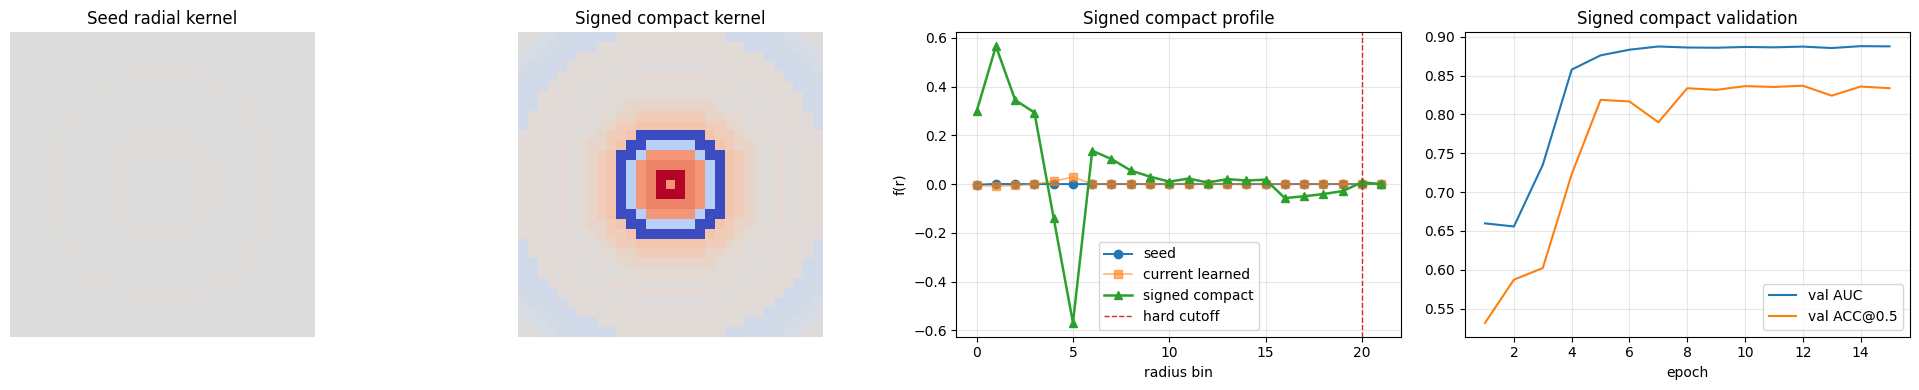

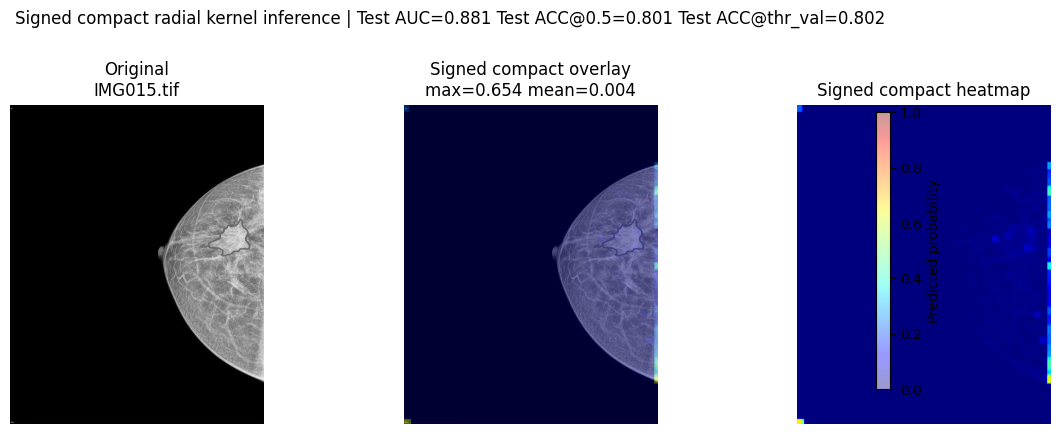


Saved signed compact artifacts to results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/signed_compact_r20


In [13]:

# Optional: signed, compact, more identifiable radial fit.
# This cell addresses the main ambiguities of the original setup:
# 1) use a signed response instead of abs_max
# 2) set f(r)=0 for r > LEARNED_RADIUS_MAX
# 3) add monotone/decay regularization on |f(r)|
# 4) normalize kernel scale and fix the sign convention by forcing f(0) > 0

SIGNED_RESPONSE_NAME = "signed_peak"
SIGNED_EPOCHS = EPOCHS
SIGNED_LR_PROFILE = LR_F * 0.5
SIGNED_LR_HEAD = LR_HEAD
SIGNED_LAMBDA_ANCHOR = 5e-2
SIGNED_LAMBDA_SMOOTH = LAMBDA_SMOOTH
SIGNED_LAMBDA_MONO = 1e-1
SIGNED_LAMBDA_DECAY = 1e-1
SIGNED_LAMBDA_EDGE = 5e-2
SIGNED_OUT_DIR = OUT_DIR / f"signed_compact_r{LEARNED_RADIUS_MAX}"
SIGNED_OUT_DIR.mkdir(parents=True, exist_ok=True)

signed_basis_t = basis_t if "basis_t" in globals() else torch.from_numpy(basis_np).to(DEVICE)
signed_train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

compact_len = min(int(LEARNED_RADIUS_MAX), full_radius_count - 1) + 1
zero_tail_len = full_radius_count - compact_len
zero_tail_t = torch.zeros(zero_tail_len, dtype=torch.float32, device=DEVICE)
radius_support_t = torch.arange(compact_len, dtype=torch.float32, device=DEVICE)
if compact_len > 1:
    radius_support_t = radius_support_t / float(compact_len - 1)

reference_source = f_best_full if "f_best_full" in globals() else f_seed_full
reference_full = np.zeros((full_radius_count,), dtype=np.float32)
reference_full[:compact_len] = reference_source[:compact_len]
if reference_full[0] < 0:
    reference_full[:compact_len] *= -1.0
ref_norm = float(np.linalg.norm(reference_full[:compact_len]))
if ref_norm < 1e-8:
    reference_full[0] = 1.0
    ref_norm = 1.0
reference_full[:compact_len] /= ref_norm
reference_support = reference_full[:compact_len].copy()
reference_support_t = torch.from_numpy(reference_support).to(DEVICE)


def inverse_softplus_scalar(x: float):
    x = max(float(x), 1e-6)
    return x if x > 20.0 else float(np.log(np.expm1(x)))


def signed_peak_response(x_t: torch.Tensor, kernel2d_t: torch.Tensor):
    out = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    flat = out[:, 0].reshape(out.shape[0], -1)
    idx = flat.abs().argmax(dim=1, keepdim=True)
    return flat.gather(1, idx).squeeze(1)


@torch.no_grad()
def extract_signed_peak_responses(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = signed_peak_response(xb, kernel2d_t)
        feats.append(feat.detach().cpu().numpy())
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,), dtype=np.float32)


@torch.no_grad()
def dense_signed_peak_feature_map(x_t: torch.Tensor, kernel2d_t: torch.Tensor, pool_window: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    xb = x_t.to(DEVICE, non_blocking=True)
    out = F.conv2d(xb, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    abs_out = out.abs()

    pool_window = max(int(pool_window), 1)
    if pool_window == 1:
        peak_map = out
    else:
        pad = pool_window // 2
        _, idx = F.max_pool2d(abs_out, kernel_size=pool_window, stride=1, padding=pad, return_indices=True)
        flat_out = out.reshape(out.shape[0], out.shape[1], -1)
        peak_map = flat_out.gather(2, idx.reshape(idx.shape[0], idx.shape[1], -1)).reshape_as(idx)
        peak_map = peak_map[..., : out.shape[-2], : out.shape[-1]]

    return (
        out[0, 0].detach().cpu().numpy().astype(np.float32),
        peak_map[0, 0].detach().cpu().numpy().astype(np.float32),
    )


def build_signed_compact_kernel(center_param_t: torch.Tensor, rest_param_t: torch.Tensor):
    center_value = F.softplus(center_param_t).reshape(1) + 1e-6
    if compact_len > 1:
        support_t = torch.cat([center_value, rest_param_t], dim=0)
    else:
        support_t = center_value
    full_t = torch.cat([support_t, zero_tail_t], dim=0) if zero_tail_len > 0 else support_t
    full_t = full_t / (torch.norm(full_t) + 1e-8)
    kernel_t = torch.einsum("r,rhw->hw", full_t, signed_basis_t)
    return kernel_t, full_t, support_t


center_init = float(reference_support[0])
rest_init = reference_support[1:].astype(np.float32) if compact_len > 1 else np.zeros((0,), dtype=np.float32)

signed_center_param = torch.nn.Parameter(
    torch.tensor(inverse_softplus_scalar(center_init), dtype=torch.float32, device=DEVICE)
)
signed_rest_param = torch.nn.Parameter(torch.from_numpy(rest_init).to(DEVICE))
signed_head_w = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float32, device=DEVICE))
signed_head_b = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=DEVICE))

signed_optimizer = torch.optim.Adam(
    [
        {"params": [signed_center_param, signed_rest_param], "lr": SIGNED_LR_PROFILE},
        {"params": [signed_head_w, signed_head_b], "lr": SIGNED_LR_HEAD},
    ]
)
signed_loss_fn = torch.nn.BCEWithLogitsLoss()
signed_best_state = None
signed_best_val_auc = -float("inf")
signed_history = []

for epoch in range(1, SIGNED_EPOCHS + 1):
    total_loss = 0.0
    n_seen = 0

    for xb, yb in signed_train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        signed_kernel_t, signed_full_t, signed_support_t = build_signed_compact_kernel(
            signed_center_param,
            signed_rest_param,
        )
        signed_feat = signed_peak_response(xb, signed_kernel_t)
        signed_logits = signed_head_w * signed_feat + signed_head_b

        signed_loss_cls = signed_loss_fn(signed_logits, yb)
        signed_loss_anchor = torch.mean((signed_support_t - reference_support_t) ** 2)
        signed_loss_smooth = (
            torch.mean((signed_support_t[1:] - signed_support_t[:-1]) ** 2)
            if compact_len > 1
            else torch.tensor(0.0, device=DEVICE)
        )
        signed_abs_support = signed_support_t.abs()
        signed_loss_mono = (
            torch.mean(torch.relu(signed_abs_support[1:] - signed_abs_support[:-1]) ** 2)
            if compact_len > 1
            else torch.tensor(0.0, device=DEVICE)
        )
        signed_loss_decay = torch.mean((radius_support_t ** 2) * (signed_support_t ** 2))
        signed_loss_edge = signed_support_t[-1] ** 2
        signed_loss = (
            signed_loss_cls
            + SIGNED_LAMBDA_ANCHOR * signed_loss_anchor
            + SIGNED_LAMBDA_SMOOTH * signed_loss_smooth
            + SIGNED_LAMBDA_MONO * signed_loss_mono
            + SIGNED_LAMBDA_DECAY * signed_loss_decay
            + SIGNED_LAMBDA_EDGE * signed_loss_edge
        )

        signed_optimizer.zero_grad()
        signed_loss.backward()
        signed_optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(signed_loss.item()) * batch_n
        n_seen += batch_n

    signed_kernel_val_t, _, _ = build_signed_compact_kernel(
        signed_center_param,
        signed_rest_param,
    )
    signed_val_resp = extract_signed_peak_responses(X_val_t, signed_kernel_val_t.detach(), BATCH_SIZE)
    signed_val_probs = sigmoid_np(
        float(signed_head_w.detach().cpu()) * signed_val_resp + float(signed_head_b.detach().cpu())
    )
    signed_val_metrics = metrics_from_probs(y_val, signed_val_probs, threshold=0.5)

    signed_history.append(
        {
            "epoch": int(epoch),
            "loss": float(total_loss / max(n_seen, 1)),
            "val_auc": float(signed_val_metrics["auc"]),
            "val_acc": float(signed_val_metrics["acc"]),
            "optimizer_head_w": float(signed_head_w.detach().cpu()),
            "optimizer_head_b": float(signed_head_b.detach().cpu()),
        }
    )

    if signed_val_metrics["auc"] > signed_best_val_auc:
        signed_best_val_auc = signed_val_metrics["auc"]
        signed_best_state = {
            "epoch": int(epoch),
            "center_param": signed_center_param.detach().cpu().clone(),
            "rest_param": signed_rest_param.detach().cpu().clone(),
            "optimizer_head_w": float(signed_head_w.detach().cpu()),
            "optimizer_head_b": float(signed_head_b.detach().cpu()),
            "val_auc": float(signed_val_metrics["auc"]),
            "val_acc": float(signed_val_metrics["acc"]),
        }

    print(
        f"signed epoch={epoch:02d} "
        f"loss={signed_history[-1]['loss']:.6f} "
        f"val_auc={signed_val_metrics['auc']:.6f} "
        f"val_acc={signed_val_metrics['acc']:.6f} "
        f"w={float(signed_head_w.detach().cpu()):+.4f} "
        f"b={float(signed_head_b.detach().cpu()):+.4f}"
    )

print("\nRestoring best signed compact checkpoint:")
print(signed_best_state)

signed_center_best = signed_best_state["center_param"].to(DEVICE)
signed_rest_best = signed_best_state["rest_param"].to(DEVICE)
signed_optimizer_head_w_best = float(signed_best_state["optimizer_head_w"])
signed_optimizer_head_b_best = float(signed_best_state["optimizer_head_b"])

with torch.no_grad():
    kernel_best_signed_t, f_best_full_signed_t, f_best_support_signed_t = build_signed_compact_kernel(
        signed_center_best,
        signed_rest_best,
    )

kernel_best_signed = kernel_best_signed_t.detach().cpu().numpy().astype(np.float32)
f_best_full_signed = f_best_full_signed_t.detach().cpu().numpy().astype(np.float32)
f_best_support_signed = f_best_support_signed_t.detach().cpu().numpy().astype(np.float32)

train_resp_signed = extract_signed_peak_responses(X_train_t, kernel_best_signed_t.detach(), BATCH_SIZE)
val_resp_signed = extract_signed_peak_responses(X_val_t, kernel_best_signed_t.detach(), BATCH_SIZE)
test_resp_signed = extract_signed_peak_responses(X_test_t, kernel_best_signed_t.detach(), BATCH_SIZE)

calib_mu_signed = float(train_resp_signed.mean())
calib_std_signed = float(train_resp_signed.std())
calib_std_signed = calib_std_signed if calib_std_signed > 1e-8 else 1.0

calib_clf_signed = LogisticRegression(max_iter=1000)
calib_clf_signed.fit(((train_resp_signed - calib_mu_signed) / calib_std_signed).reshape(-1, 1), y_train)

calib_w_signed = float(calib_clf_signed.coef_[0, 0])
calib_b_signed = float(calib_clf_signed.intercept_[0])

train_probs_signed = calib_clf_signed.predict_proba(((train_resp_signed - calib_mu_signed) / calib_std_signed).reshape(-1, 1))[:, 1]
val_probs_signed = calib_clf_signed.predict_proba(((val_resp_signed - calib_mu_signed) / calib_std_signed).reshape(-1, 1))[:, 1]
test_probs_signed = calib_clf_signed.predict_proba(((test_resp_signed - calib_mu_signed) / calib_std_signed).reshape(-1, 1))[:, 1]

signed_threshold_val, signed_val_acc_tuned = best_threshold_by_accuracy(y_val, val_probs_signed, THRESHOLD_GRID_SIZE)

learned_results_signed = {
    "val_05": metrics_from_probs(y_val, val_probs_signed, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs_signed, threshold=signed_threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs_signed, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs_signed, threshold=signed_threshold_val),
    "threshold_val": float(signed_threshold_val),
    "best_epoch": int(signed_best_state["epoch"]),
    "optimizer_head_w": signed_optimizer_head_w_best,
    "optimizer_head_b": signed_optimizer_head_b_best,
    "calib_mu": calib_mu_signed,
    "calib_std": calib_std_signed,
    "calib_w": calib_w_signed,
    "calib_b": calib_b_signed,
    "response_mode": SIGNED_RESPONSE_NAME,
    "compact_radius_max": int(compact_len - 1),
}

print("\nCalibrated signed compact radial-kernel metrics:")
print(
    f"  Val  | AUC={learned_results_signed['val_05']['auc']:.6f} ACC@0.5={learned_results_signed['val_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_signed['val_tuned']['acc']:.6f} (thr_val={learned_results_signed['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={learned_results_signed['test_05']['auc']:.6f} ACC@0.5={learned_results_signed['test_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_signed['test_tuned']['acc']:.6f}"
)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
signed_vmax = max(
    float(np.max(np.abs(seed_radial_kernel))),
    float(np.max(np.abs(kernel_best_signed))),
    float(np.max(np.abs(kernel_best))) if "kernel_best" in globals() else 0.0,
) + 1e-12

axes[0].imshow(seed_radial_kernel, cmap="coolwarm", vmin=-signed_vmax, vmax=signed_vmax)
axes[0].set_title("Seed radial kernel")
axes[0].axis("off")

axes[1].imshow(kernel_best_signed, cmap="coolwarm", vmin=-signed_vmax, vmax=signed_vmax)
axes[1].set_title("Signed compact kernel")
axes[1].axis("off")

axes[2].plot(np.arange(len(f_seed_full)), f_seed_full, marker="o", linewidth=1.4, label="seed")
if "f_best_full" in globals():
    axes[2].plot(np.arange(len(f_best_full)), f_best_full, marker="s", linewidth=1.1, alpha=0.6, label="current learned")
axes[2].plot(np.arange(len(f_best_full_signed)), f_best_full_signed, marker="^", linewidth=1.8, label="signed compact")
axes[2].axvline(compact_len - 1, color="tab:red", linestyle="--", linewidth=1, label="hard cutoff")
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Signed compact profile")
axes[2].grid(alpha=0.3)
axes[2].legend()

signed_epochs = np.array([row["epoch"] for row in signed_history], dtype=int)
signed_val_auc_curve = np.array([row["val_auc"] for row in signed_history], dtype=np.float32)
signed_val_acc_curve = np.array([row["val_acc"] for row in signed_history], dtype=np.float32)
axes[3].plot(signed_epochs, signed_val_auc_curve, label="val AUC")
axes[3].plot(signed_epochs, signed_val_acc_curve, label="val ACC@0.5")
axes[3].set_xlabel("epoch")
axes[3].set_title("Signed compact validation")
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

signed_example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
signed_img_arr = np.array(Image.open(signed_example_path).convert("L"), dtype=np.float32) / 255.0
signed_x_img_t = to_tensor_batch(signed_img_arr[None, ...].astype(np.float32), torch.device("cpu"))
if STANDARDIZE_PATCHES:
    signed_x_img_t = patch_standardize(signed_x_img_t)

signed_heatmap_window = RESIZE_PATCH if (RESIZE_PATCH % 2 == 1) else (RESIZE_PATCH - 1)
signed_raw_map, signed_feature_map = dense_signed_peak_feature_map(
    signed_x_img_t,
    torch.from_numpy(kernel_best_signed),
    pool_window=signed_heatmap_window,
)

prob_map_signed = sigmoid_np(
    calib_w_signed * ((signed_feature_map - calib_mu_signed) / calib_std_signed) + calib_b_signed
).astype(np.float32)
prob_map_vis_signed = gaussian_filter(prob_map_signed, sigma=float(HEATMAP_SMOOTH_SIGMA)) if HEATMAP_SMOOTH_SIGMA > 0 else prob_map_signed
signed_score_max = float(prob_map_signed.max())
signed_score_mean = float(prob_map_signed.mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(signed_img_arr, cmap="gray")
axes[0].set_title(f"Original\n{signed_example_path.name}")
axes[0].axis("off")

axes[1].imshow(signed_img_arr, cmap="gray")
signed_im = axes[1].imshow(
    prob_map_vis_signed,
    cmap="jet",
    alpha=DENSE_OVERLAY_ALPHA,
    vmin=0.0,
    vmax=1.0,
    interpolation="bilinear",
)
axes[1].set_title(
    "Signed compact overlay\n"
    f"max={signed_score_max:.3f} mean={signed_score_mean:.3f}"
)
axes[1].axis("off")

axes[2].imshow(prob_map_vis_signed, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[2].set_title("Signed compact heatmap")
axes[2].axis("off")

fig.suptitle(
    "Signed compact radial kernel inference | "
    f"Test AUC={learned_results_signed['test_05']['auc']:.3f} "
    f"Test ACC@0.5={learned_results_signed['test_05']['acc']:.3f} "
    f"Test ACC@thr_val={learned_results_signed['test_tuned']['acc']:.3f}",
    y=1.03,
)
cbar = fig.colorbar(signed_im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Predicted probability")
fig.subplots_adjust(top=0.82, wspace=0.05)
plt.show()

signed_summary = {
    "reference_support": [float(x) for x in reference_support],
    "f_signed_full": [float(x) for x in f_best_full_signed],
    "f_signed_support": [float(x) for x in f_best_support_signed],
    "learned_signed": learned_results_signed,
    "history_signed": signed_history,
    "signed_response_name": SIGNED_RESPONSE_NAME,
}

if SAVE_ARTIFACTS:
    np.save(SIGNED_OUT_DIR / "f_signed_full.npy", f_best_full_signed.astype(np.float32))
    np.save(SIGNED_OUT_DIR / "kernel_signed_compact.npy", kernel_best_signed.astype(np.float32))
    np.save(SIGNED_OUT_DIR / f"{signed_example_path.stem}_signed_prob_map.npy", prob_map_signed)
    fig.savefig(SIGNED_OUT_DIR / f"{signed_example_path.stem}_signed_heatmap.png", dpi=260, bbox_inches="tight")
    (SIGNED_OUT_DIR / "signed_compact_summary.json").write_text(json.dumps(signed_summary, indent=2))
    print(f"\nSaved signed compact artifacts to {SIGNED_OUT_DIR}")


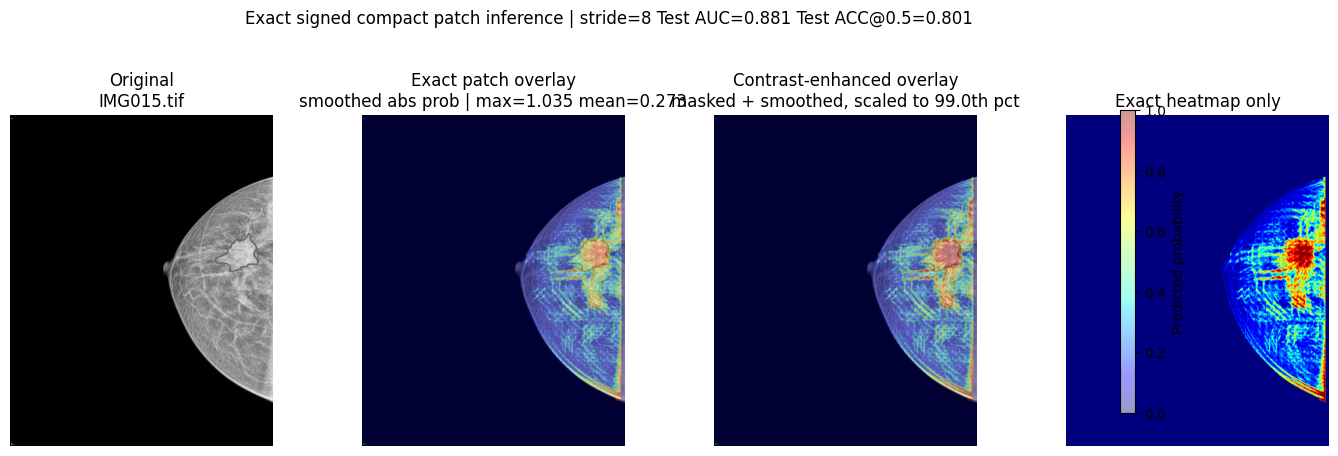

Exact heatmap stats: max=1.034972 mean_all=0.059633 mean_breast=0.273190
Exact heatmap grid size: (750, 595) with stride=8
Saved exact heatmap figure: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/signed_compact_r20/exact_patch_heatmap/IMG015_signed_exact_heatmap.png
Saved exact probability map: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/signed_compact_r20/exact_patch_heatmap/IMG015_signed_exact_prob_map.npy
Saved exact probability grid: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/signed_compact_r20/exact_patch_heatmap/IMG015_signed_exact_prob_grid.npy


In [17]:

# Exact patch-level heatmap for the signed compact model.
# This evaluates the same patch classifier used in training on a sliding grid over the image.
# It is slower than the fast dense map, but it is the correct full-image inference path.

EXACT_HEATMAP_STRIDE = 8
EXACT_HEATMAP_ROW_BLOCK = 24
EXACT_HEATMAP_BATCH_PATCHES = 128
EXACT_HEATMAP_MASK_THRESHOLD = 0.02
EXACT_HEATMAP_DISPLAY_PERCENTILE = 99.0
EXACT_HEATMAP_ALPHA = min(float(DENSE_OVERLAY_ALPHA), 0.55)
EXACT_HEATMAP_EXTRA_SMOOTH_SIGMA = max(float(HEATMAP_SMOOTH_SIGMA), float(EXACT_HEATMAP_STRIDE) * 0.90)
EXACT_HEATMAP_BREAST_EROSION = max(2, RESIZE_PATCH // 12)
EXACT_HEATMAP_OUT_DIR = SIGNED_OUT_DIR / "exact_patch_heatmap"
EXACT_HEATMAP_OUT_DIR.mkdir(parents=True, exist_ok=True)

if "kernel_best_signed" not in globals():
    raise RuntimeError("Run the signed-identifiable-fit cell first.")

from scipy.ndimage import binary_erosion


def exact_signed_patch_prob_grid(
    image_np: np.ndarray,
    kernel_np: np.ndarray,
    patch_size: int,
    stride: int,
    batch_patches: int,
    row_block: int,
):
    image_t = to_tensor_batch(image_np[None, ...].astype(np.float32), torch.device("cpu"))
    h, w = image_np.shape

    pad_top = patch_size // 2
    pad_left = patch_size // 2
    pad_bottom = patch_size - pad_top - 1
    pad_right = patch_size - pad_left - 1
    padded = F.pad(image_t, (pad_left, pad_right, pad_top, pad_bottom), mode="constant", value=0.0)

    y_positions = list(range(0, h, stride))
    x_positions = list(range(0, w, stride))
    feat_grid = np.zeros((len(y_positions), len(x_positions)), dtype=np.float32)
    kernel_t = torch.from_numpy(kernel_np).to(DEVICE)

    for row_start in range(0, len(y_positions), row_block):
        block_rows = y_positions[row_start : row_start + row_block]
        y0 = block_rows[0]
        y_last = block_rows[-1]
        crop_h = (len(block_rows) - 1) * stride + patch_size
        crop = padded[:, :, y0 : y0 + crop_h, :]

        patches_unfold = F.unfold(crop, kernel_size=(patch_size, patch_size), stride=(stride, stride))
        patches = patches_unfold.transpose(1, 2).reshape(-1, 1, patch_size, patch_size).contiguous()

        if STANDARDIZE_PATCHES:
            patches = patch_standardize(patches)

        block_feats = []
        for i in range(0, patches.shape[0], batch_patches):
            pb = patches[i : i + batch_patches].to(DEVICE, non_blocking=True)
            feat = signed_peak_response(pb, kernel_t)
            block_feats.append(feat.detach().cpu().numpy())

        block_feats = np.concatenate(block_feats, axis=0).astype(np.float32)
        feat_grid[row_start : row_start + len(block_rows), :] = block_feats.reshape(len(block_rows), len(x_positions))

    return feat_grid, np.array(y_positions, dtype=np.int64), np.array(x_positions, dtype=np.int64)


exact_example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
exact_img_arr = np.array(Image.open(exact_example_path).convert("L"), dtype=np.float32) / 255.0

feat_grid_signed, y_grid_signed, x_grid_signed = exact_signed_patch_prob_grid(
    exact_img_arr,
    kernel_best_signed,
    patch_size=RESIZE_PATCH,
    stride=EXACT_HEATMAP_STRIDE,
    batch_patches=EXACT_HEATMAP_BATCH_PATCHES,
    row_block=EXACT_HEATMAP_ROW_BLOCK,
)

prob_grid_signed = sigmoid_np(
    calib_w_signed * ((feat_grid_signed - calib_mu_signed) / calib_std_signed) + calib_b_signed
).astype(np.float32)

prob_map_exact_signed = F.interpolate(
    torch.from_numpy(prob_grid_signed)[None, None],
    size=exact_img_arr.shape,
    mode="bicubic",
    align_corners=False,
)[0, 0].cpu().numpy().astype(np.float32)

h_img, w_img = exact_img_arr.shape
pad_top = RESIZE_PATCH // 2
pad_left = RESIZE_PATCH // 2
pad_bottom = RESIZE_PATCH - pad_top - 1
pad_right = RESIZE_PATCH - pad_left - 1
valid_center_mask_signed = np.zeros_like(exact_img_arr, dtype=np.float32)
valid_center_mask_signed[pad_top : h_img - pad_bottom, pad_left : w_img - pad_right] = 1.0

breast_mask_signed = exact_img_arr > float(EXACT_HEATMAP_MASK_THRESHOLD)
display_mask_signed = binary_erosion(
    breast_mask_signed,
    iterations=int(EXACT_HEATMAP_BREAST_EROSION),
).astype(np.float32)
display_mask_signed *= valid_center_mask_signed

smooth_num = gaussian_filter(
    prob_map_exact_signed * display_mask_signed,
    sigma=float(EXACT_HEATMAP_EXTRA_SMOOTH_SIGMA),
)
smooth_den = gaussian_filter(display_mask_signed, sigma=float(EXACT_HEATMAP_EXTRA_SMOOTH_SIGMA))
prob_map_exact_vis_signed = smooth_num / np.maximum(smooth_den, 1e-6)
prob_map_exact_vis_signed *= display_mask_signed

if display_mask_signed.any():
    masked_vals = prob_map_exact_vis_signed[display_mask_signed > 0]
    display_hi = float(np.percentile(masked_vals, EXACT_HEATMAP_DISPLAY_PERCENTILE))
else:
    masked_vals = prob_map_exact_vis_signed.ravel()
    display_hi = float(np.percentile(masked_vals, EXACT_HEATMAP_DISPLAY_PERCENTILE))

display_hi = max(display_hi, 1e-6)
prob_map_exact_display_signed = np.clip(prob_map_exact_vis_signed / display_hi, 0.0, 1.0).astype(np.float32)
prob_map_exact_display_signed *= display_mask_signed.astype(np.float32)

# Final display-only smoothing to remove residual stride artifacts after upsampling.
prob_map_exact_display_signed = gaussian_filter(
    prob_map_exact_display_signed,
    sigma=max(1.0, float(EXACT_HEATMAP_STRIDE) * 0.35),
).astype(np.float32)
prob_map_exact_display_signed *= display_mask_signed.astype(np.float32)
prob_map_exact_display_signed = np.clip(prob_map_exact_display_signed, 0.0, 1.0)

exact_score_max = float((prob_map_exact_signed * display_mask_signed).max())
exact_score_mean = float(prob_map_exact_signed.mean())
exact_score_mean_breast = float(masked_vals.mean()) if masked_vals.size > 0 else float(prob_map_exact_signed.mean())

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
axes[0].imshow(exact_img_arr, cmap="gray")
axes[0].set_title(f"Original\n{exact_example_path.name}")
axes[0].axis("off")

axes[1].imshow(exact_img_arr, cmap="gray")
im1 = axes[1].imshow(
    prob_map_exact_vis_signed,
    cmap="jet",
    alpha=EXACT_HEATMAP_ALPHA,
    vmin=0.0,
    vmax=1.0,
    interpolation="bilinear",
)
axes[1].set_title(
    "Exact patch overlay\n"
    f"smoothed abs prob | max={exact_score_max:.3f} mean={exact_score_mean_breast:.3f}"
)
axes[1].axis("off")

axes[2].imshow(exact_img_arr, cmap="gray")
axes[2].imshow(
    prob_map_exact_display_signed,
    cmap="jet",
    alpha=EXACT_HEATMAP_ALPHA,
    vmin=0.0,
    vmax=1.0,
    interpolation="bilinear",
)
axes[2].set_title(
    "Contrast-enhanced overlay\n"
    f"masked + smoothed, scaled to {EXACT_HEATMAP_DISPLAY_PERCENTILE:.1f}th pct"
)
axes[2].axis("off")

axes[3].imshow(prob_map_exact_display_signed, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[3].set_title("Exact heatmap only")
axes[3].axis("off")

fig.suptitle(
    "Exact signed compact patch inference | "
    f"stride={EXACT_HEATMAP_STRIDE} "
    f"Test AUC={learned_results_signed['test_05']['auc']:.3f} "
    f"Test ACC@0.5={learned_results_signed['test_05']['acc']:.3f}",
    y=1.02,
)

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.82)
cbar.set_label("Predicted probability")
fig.subplots_adjust(top=0.80, wspace=0.04)
plt.show()

print(f"Exact heatmap stats: max={exact_score_max:.6f} mean_all={exact_score_mean:.6f} mean_breast={exact_score_mean_breast:.6f}")
print(f"Exact heatmap grid size: {prob_grid_signed.shape} with stride={EXACT_HEATMAP_STRIDE}")

if SAVE_ARTIFACTS:
    exact_fig_path = EXACT_HEATMAP_OUT_DIR / f"{exact_example_path.stem}_signed_exact_heatmap.png"
    exact_prob_path = EXACT_HEATMAP_OUT_DIR / f"{exact_example_path.stem}_signed_exact_prob_map.npy"
    exact_prob_grid_path = EXACT_HEATMAP_OUT_DIR / f"{exact_example_path.stem}_signed_exact_prob_grid.npy"
    fig.savefig(exact_fig_path, dpi=260, bbox_inches="tight")
    np.save(exact_prob_path, prob_map_exact_signed)
    np.save(exact_prob_grid_path, prob_grid_signed)
    print(f"Saved exact heatmap figure: {exact_fig_path}")
    print(f"Saved exact probability map: {exact_prob_path}")
    print(f"Saved exact probability grid: {exact_prob_grid_path}")
